In [1]:
!pip install pylibjpeg pylibjpeg-libjpeg python-gdcm mlflow -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 42.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 99.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 102.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.4/808.4 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 15.8 MB/s eta 0:00:00


In [3]:
# CELL 2: Import all libraries
import numpy as np
import pylibjpeg
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import mlflow
import mlflow.pytorch
import time
import warnings
warnings.filterwarnings('ignore')


In [4]:
# CELL 3: Setup paths and load data
BASE = "/kaggle/input/rsna-2022-cervical-spine-fracture-detection"

# Load labels
train_df = pd.read_csv(f"{BASE}/train.csv")
print(f"Total patients: {len(train_df)}")
print(train_df.head())

# Split data
train_data, val_data = train_test_split(train_df, test_size=0.2, random_state=42)
print(f"\nTrain: {len(train_data)}, Val: {len(val_data)}")

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n✓ Using device: {device}")

Total patients: 2019
            StudyInstanceUID  patient_overall  C1  C2  C3  C4  C5  C6  C7
0   1.2.826.0.1.3680043.6200                1   1   1   0   0   0   0   0
1  1.2.826.0.1.3680043.27262                1   0   1   0   0   0   0   0
2  1.2.826.0.1.3680043.21561                1   0   1   0   0   0   0   0
3  1.2.826.0.1.3680043.12351                0   0   0   0   0   0   0   0
4   1.2.826.0.1.3680043.1363                1   0   0   0   0   1   0   0

Train: 1615, Val: 404

✓ Using device: cuda


In [7]:
# CELL 4: Utility functions
def apply_window(image, center=400, width=1000):
    """Apply CT windowing for bone visibility"""
    image = image.astype(np.float32)
    low = center - width // 2
    high = center + width // 2
    image = np.clip(image, low, high)
    image = (image - low) / (high - low)
    return image



In [8]:
# CELL 5: Dataset - SINGLE SLICE (Original)
class SpineDatasetSingle(Dataset):
    """Original dataset - uses only middle slice"""
    def __init__(self, df, base_path, img_size=512):
        self.df = df.reset_index(drop=True)
        self.base_path = Path(base_path)
        self.img_size = img_size
        self.label_cols = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        patient_id = row['StudyInstanceUID']
        
        patient_path = self.base_path / "train_images" / patient_id
        slices = sorted(patient_path.glob("*.dcm"))
        mid_idx = len(slices) // 2
        
        # Load single middle slice
        dcm = pydicom.dcmread(slices[mid_idx])
        image = dcm.pixel_array.astype(np.float32)
        image = apply_window(image)
        
        # Resize
        image = torch.tensor(image).unsqueeze(0).unsqueeze(0)
        image = F.interpolate(image, size=(self.img_size, self.img_size), mode='bilinear')
        image = image.squeeze(0)  # (1, H, W)
        
        labels = torch.tensor(row[self.label_cols].values.astype(np.float32))
        return image, labels

print("✓ SpineDatasetSingle defined!")

✓ SpineDatasetSingle defined!


In [9]:
# CELL 6: Dataset - 3-CHANNEL (2.5D) - IMPROVED!
class SpineDataset3Channel(Dataset):
    """2.5D approach - 3 consecutive slices as input"""
    def __init__(self, df, base_path, img_size=512):
        self.df = df.reset_index(drop=True)
        self.base_path = Path(base_path)
        self.img_size = img_size
        self.label_cols = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        patient_id = row['StudyInstanceUID']
        
        patient_path = self.base_path / "train_images" / patient_id
        slice_files = sorted(patient_path.glob("*.dcm"))
        total_slices = len(slice_files)
        mid_idx = total_slices // 2
        
        # Get 3 slices: middle-1, middle, middle+1
        indices = [
            max(0, mid_idx - 1),
            mid_idx,
            min(total_slices - 1, mid_idx + 1)
        ]
        
        images = []
        for i in indices:
            dcm = pydicom.dcmread(slice_files[i])
            img = dcm.pixel_array.astype(np.float32)
            img = apply_window(img)
            images.append(img)
        
        # Stack as 3-channel image
        image = np.stack(images, axis=0)  # (3, H, W)
        
        # Resize
        image = torch.tensor(image).unsqueeze(0)
        image = F.interpolate(image, size=(self.img_size, self.img_size), mode='bilinear')
        image = image.squeeze(0)  # (3, H, W)
        
        labels = torch.tensor(row[self.label_cols].values.astype(np.float32))
        return image, labels

print("✓ SpineDataset3Channel defined!")

✓ SpineDataset3Channel defined!


In [10]:
# CELL 7: Model definitions
class SpineModelSingle(nn.Module):
    """Model for single channel input (1 slice)"""
    def __init__(self, num_classes=7):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights='IMAGENET1K_V1')
        self.backbone.features[0][0] = nn.Conv2d(
            1, 32, kernel_size=3, stride=2, padding=1, bias=False
        )
        self.backbone.classifier[1] = nn.Linear(1280, num_classes)
    
    def forward(self, x):
        return self.backbone(x)

class SpineModel3Channel(nn.Module):
    """Model for 3-channel input (2.5D)"""
    def __init__(self, num_classes=7):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights='IMAGENET1K_V1')
        # Keep original 3-channel input (pretrained weights work!)
        self.backbone.classifier[1] = nn.Linear(1280, num_classes)
    
    def forward(self, x):
        return self.backbone(x)

print("✓ Models defined!")

✓ Models defined!


In [11]:
# CELL 8: Training functions
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    return total_loss / len(loader)

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            probs = torch.sigmoid(outputs)
            all_preds.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    
    # Calculate metrics
    accuracy = ((all_preds > 0.5) == all_labels).mean()
    
    # AUC for each class
    auc_scores = []
    for i in range(all_labels.shape[1]):
        if len(np.unique(all_labels[:, i])) > 1:
            auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
            auc_scores.append(auc)
    mean_auc = np.mean(auc_scores) if auc_scores else 0.0
    
    return total_loss / len(loader), accuracy, mean_auc

print("✓ Training functions defined!")

✓ Training functions defined!


In [12]:
# CELL 9: Experiment runner with MLflow
def run_experiment(experiment_name, model, train_loader, val_loader, 
                   num_epochs=3, lr=1e-4, device='cuda'):
    """Run experiment with MLflow tracking"""
    
    mlflow.set_experiment("Spine_Fracture_Detection")
    
    with mlflow.start_run(run_name=experiment_name):
        # Log parameters
        mlflow.log_param("experiment_name", experiment_name)
        mlflow.log_param("num_epochs", num_epochs)
        mlflow.log_param("learning_rate", lr)
        mlflow.log_param("batch_size", train_loader.batch_size)
        
        model = model.to(device)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        
        best_val_loss = float('inf')
        best_auc = 0.0
        history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
        
        start_time = time.time()
        
        for epoch in range(num_epochs):
            train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
            val_loss, val_acc, val_auc = validate(model, val_loader, criterion, device)
            
            # Log to MLflow
            mlflow.log_metric("train_loss", train_loss, step=epoch)
            mlflow.log_metric("val_loss", val_loss, step=epoch)
            mlflow.log_metric("val_accuracy", val_acc, step=epoch)
            mlflow.log_metric("val_auc", val_auc, step=epoch)
            
            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            history['val_auc'].append(val_auc)
            
            print(f"Epoch {epoch+1}/{num_epochs}")
            print(f"  Train Loss: {train_loss:.4f}")
            print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val AUC: {val_auc:.4f}")
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_auc = val_auc
                torch.save(model.state_dict(), f"best_model_{experiment_name}.pth")
                print("  ✓ Saved best model!")
            print()
        
        training_time = time.time() - start_time
        mlflow.log_metric("best_val_loss", best_val_loss)
        mlflow.log_metric("best_val_auc", best_auc)
        mlflow.log_metric("training_time", training_time)
        
        print(f"✓ {experiment_name} Complete!")
        print(f"  Best Val Loss: {best_val_loss:.4f}")
        print(f"  Best Val AUC: {best_auc:.4f}")
        print(f"  Time: {training_time:.1f}s")
        
        return history, best_val_loss, best_auc

print("✓ Experiment runner defined!")

✓ Experiment runner defined!


In [13]:
# CELL 10: EXPERIMENT 1 - Single Slice (Original)
print("=" * 60)
print("EXPERIMENT 1: Single Slice (Original)")
print("=" * 60)

# Create datasets
train_dataset_single = SpineDatasetSingle(train_data, BASE, img_size=512)
val_dataset_single = SpineDatasetSingle(val_data, BASE, img_size=512)
train_loader_single = DataLoader(train_dataset_single, batch_size=8, shuffle=True, num_workers=0)
val_loader_single = DataLoader(val_dataset_single, batch_size=8, shuffle=False, num_workers=0)

# Run experiment
model_single = SpineModelSingle()
history_single, loss_single, auc_single = run_experiment(
    "single_slice",
    model_single,
    train_loader_single,
    val_loader_single,
    num_epochs=3,
    device=device
)

EXPERIMENT 1: Single Slice (Original)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 115MB/s] 
2026/02/20 13:47:33 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/20 13:47:33 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/20 13:47:33 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/20 13:47:33 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/20 13:47:33 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/20 13:47:33 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/20 13:47:33 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/02/20 13:47:33 INFO mlflow.store.db.utils: Updating database tables
2026/02/20 13:47:33 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/20 13:47:33 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/02/20 13:47:33 INFO alembic.runtime.migration: Running upgr

Epoch 1/3
  Train Loss: 0.3676
  Val Loss: 0.3285, Val Acc: 0.9010, Val AUC: 0.4835
  ✓ Saved best model!

Epoch 2/3
  Train Loss: 0.3143
  Val Loss: 0.3164, Val Acc: 0.9013, Val AUC: 0.5169
  ✓ Saved best model!

Epoch 3/3
  Train Loss: 0.3047
  Val Loss: 0.3197, Val Acc: 0.9010, Val AUC: 0.5313

✓ single_slice Complete!
  Best Val Loss: 0.3164
  Best Val AUC: 0.5169
  Time: 247.0s


In [14]:
# CELL 11: EXPERIMENT 2 - 3-Channel (2.5D)
print("\n" + "=" * 60)
print("EXPERIMENT 2: 3-Channel (2.5D) - IMPROVED!")
print("=" * 60)

# Create datasets
train_dataset_3ch = SpineDataset3Channel(train_data, BASE, img_size=512)
val_dataset_3ch = SpineDataset3Channel(val_data, BASE, img_size=512)
train_loader_3ch = DataLoader(train_dataset_3ch, batch_size=8, shuffle=True, num_workers=0)
val_loader_3ch = DataLoader(val_dataset_3ch, batch_size=8, shuffle=False, num_workers=0)

# Run experiment
model_3ch = SpineModel3Channel()
history_3ch, loss_3ch, auc_3ch = run_experiment(
    "3_channel_2.5D",
    model_3ch,
    train_loader_3ch,
    val_loader_3ch,
    num_epochs=3,
    device=device
)


EXPERIMENT 2: 3-Channel (2.5D) - IMPROVED!
Epoch 1/3
  Train Loss: 0.3703
  Val Loss: 0.3204, Val Acc: 0.9013, Val AUC: 0.4856
  ✓ Saved best model!

Epoch 2/3
  Train Loss: 0.3100
  Val Loss: 0.3209, Val Acc: 0.9013, Val AUC: 0.5151

Epoch 3/3
  Train Loss: 0.2973
  Val Loss: 0.3140, Val Acc: 0.9017, Val AUC: 0.5429
  ✓ Saved best model!

✓ 3_channel_2.5D Complete!
  Best Val Loss: 0.3140
  Best Val AUC: 0.5429
  Time: 316.9s



COMPARISON RESULTS
      Experiment  Best Val Loss  Best Val AUC
    Single Slice       0.316438      0.516941
3-Channel (2.5D)       0.314002      0.542930


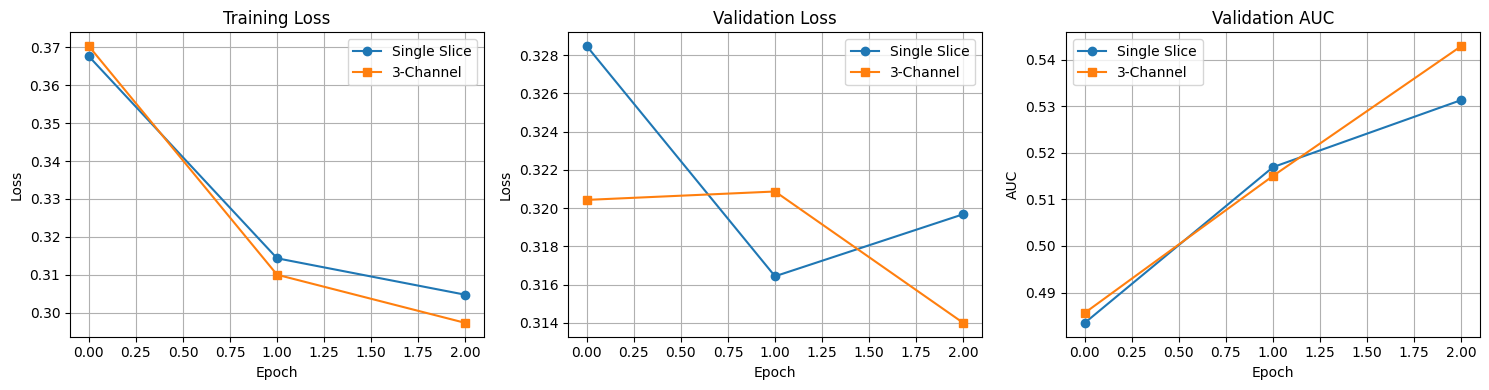

In [16]:
# CELL 12: Compare Results
print("\n" + "=" * 60)
print("COMPARISON RESULTS")
print("=" * 60)

results = pd.DataFrame({
    'Experiment': ['Single Slice', '3-Channel (2.5D)'],
    'Best Val Loss': [loss_single, loss_3ch],
    'Best Val AUC': [auc_single, auc_3ch]
})
print(results.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Training Loss
axes[0].plot(history_single['train_loss'], label='Single Slice', marker='o')
axes[0].plot(history_3ch['train_loss'], label='3-Channel', marker='s')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Validation Loss
axes[1].plot(history_single['val_loss'], label='Single Slice', marker='o')
axes[1].plot(history_3ch['val_loss'], label='3-Channel', marker='s')
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

# Validation AUC
axes[2].plot(history_single['val_auc'], label='Single Slice', marker='o')
axes[2].plot(history_3ch['val_auc'], label='3-Channel', marker='s')
axes[2].set_title('Validation AUC')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('comparison_results.png')
plt.show()



In [19]:
# CELL 13: View MLflow logged experiments
print("=" * 60)
print("MLflow Experiment Results")
print("=" * 60)

# Get all runs
runs = mlflow.search_runs()
print(runs[['run_id', 'params.experiment_name', 'metrics.best_val_loss', 'metrics.best_val_auc']])


MLflow Experiment Results
                             run_id params.experiment_name  \
0  191ff26377764689988e2c878655174d         3_channel_2.5D   
1  4a931f7ba31d43c9bbd129e348e2bcc7           single_slice   

   metrics.best_val_loss  metrics.best_val_auc  
0               0.314002              0.542930  
1               0.316438              0.516941  
